In [2]:
import zipfile
import os
import shutil
from sklearn.model_selection import train_test_split

# Unzip dataset
with zipfile.ZipFile('traffic_images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

base_dir = '/content/traffic_images'
train_dir = os.path.join(base_dir, 'training')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

# Create test set from training (15%)
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    train_imgs, test_imgs = train_test_split(images, test_size=0.15, random_state=42)

    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)
    for img in test_imgs:
        shutil.move(os.path.join(cls_path, img), os.path.join(test_dir, cls, img))


In [3]:

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
from collections import Counter

img_size = (224, 224)
batch_size = 32

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size, shuffle=True, label_mode='int'
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size, shuffle=False, label_mode='int'
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size, shuffle=False, label_mode='int'
)

# Save class names only once
class_names = train_ds.class_names
print("Class names:", class_names)

# Data augmentation
norm_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (norm_layer(data_augmentation(x, training=True)), y))
val_ds = val_ds.map(lambda x, y: (norm_layer(x), y))
test_ds = test_ds.map(lambda x, y: (norm_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Class weights to ensure balance
train_labels = []
for _, y in train_ds.unbatch():
    train_labels.append(y.numpy())

counter = Counter(train_labels)
total = sum(counter.values())
class_weight = {i: total/(len(counter) * count) for i, count in counter.items()}
print("Class weights:", class_weight)



Found 1717 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Found 305 files belonging to 4 classes.
Class names: ['minor', 'moderate', 'none', 'severe']
Class weights: {np.int32(3): 1.0812342569269522, np.int32(1): 1.0922391857506362, np.int32(2): 0.7905156537753223, np.int32(0): 1.1178385416666667}


In [4]:

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt


def plot_history(history, title_prefix=""):
    """Plot accuracy and loss"""
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()



def evaluate_model(model, dataset, class_names, plot_cm=True):
    y_true, y_pred = [], []

    for xb, yb in dataset:
        probs = model.predict(xb, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        if yb.ndim == 2:
            y_true.extend(np.argmax(yb.numpy(), axis=1))
        else:
            y_true.extend(yb.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Classification report
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Macro-F1
    print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))

    # Confusion matrix plot
    if plot_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix")
        plt.show()


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 462ms/step - accuracy: 0.3642 - loss: 1.3593 - val_accuracy: 0.5959 - val_loss: 0.9963
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 447ms/step - accuracy: 0.5285 - loss: 1.0974 - val_accuracy: 0.6254 - val_loss: 0.8366
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 449ms/step - accuracy: 0.5847 - loss: 0.9822 - val_accuracy: 0.6047 - val_loss: 0.8311
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 452ms/step - accuracy: 0.5855 - loss: 0.9176 - val_accuracy: 0.6401 - val_loss: 0.7712
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 446ms/step - accuracy: 0.6207 - loss: 0.8712 - val_accuracy: 0.6224 - val_loss: 0.7722
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 448ms/step - accuracy: 0.6326 - loss: 0.8292 - val_accuracy: 0.6578 - val_loss: 0.7558
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 451ms/step - accuracy: 0.6134 - loss: 0.8695 - val_accuracy: 0.6342 - val_loss: 0.7450
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 455ms/step - accuracy: 0.6450 - loss: 0.8245 - val_accuracy: 0.649

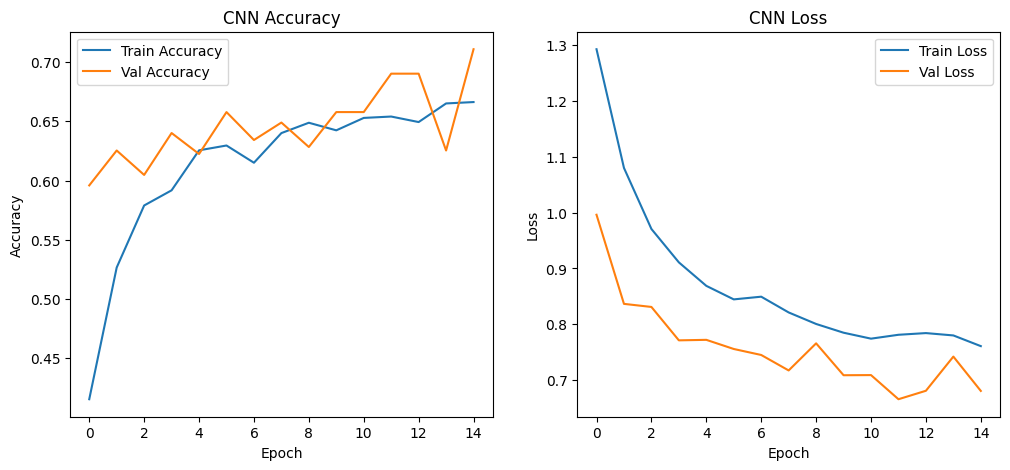


Classification report:
              precision    recall  f1-score   support

       minor       0.76      0.54      0.63        68
    moderate       0.60      0.30      0.40        70
        none       0.98      0.99      0.98        96
      severe       0.52      0.92      0.67        71

    accuracy                           0.71       305
   macro avg       0.71      0.69      0.67       305
weighted avg       0.74      0.71      0.70       305

Macro-F1: 0.6709003144236304


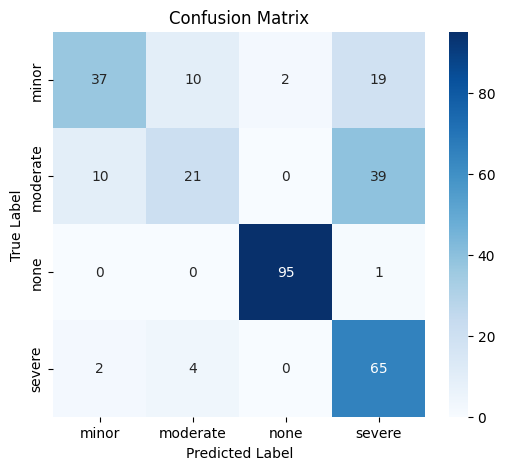

In [12]:
from tensorflow.keras import models, layers, optimizers

model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model_cnn.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_obj = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight
)

# Convert history to dict for plotting
history_cnn = history_cnn_obj.history

# Evaluate
model_cnn.evaluate(test_ds)
model_cnn.save('model1_cnn.h5')

plot_history(history_cnn, "CNN")
evaluate_model(model_cnn, test_ds, class_names)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 904ms/step - accuracy: 0.3142 - loss: 1.6736 - val_accuracy: 0.5487 - val_loss: 0.9764
Epoch 2/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 437ms/step - accuracy: 0.5464 - loss: 1.1391 - val_accuracy: 0.6254 - val_loss: 0.7964
Epoch 3/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 423ms/step - accuracy: 0.5947 - loss: 0.9928 - val_accuracy: 0.6932 - val_loss: 0.7025
Epoch 4/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 416ms/step - accuracy: 0.6496 - loss: 0.8596 - val_accuracy: 0.7050 - val_loss: 0.6685
Epoch 5/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 430ms/step - accuracy: 0.6607 - loss: 0.8247 - val_accuracy: 0.7050 - val_loss: 0.6450
Epoch 6/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 421ms/step - accuracy: 0.6679 - loss: 0.8288 - val_accuracy: 0.7080 - val_loss: 0.6362
Epoch 7/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 424ms/step - accuracy: 0.6636 - loss: 0.7837 - val_accuracy: 0.7227 - val_loss: 0.6207
Epoch 8/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 430ms/

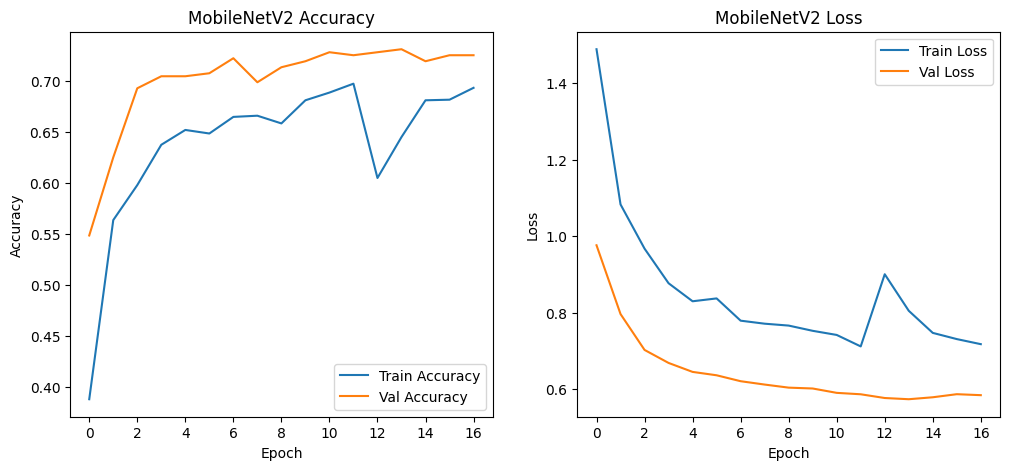


Classification report:
              precision    recall  f1-score   support

       minor       0.73      0.85      0.79        68
    moderate       0.58      0.46      0.51        70
        none       0.98      1.00      0.99        96
      severe       0.67      0.69      0.68        71

    accuracy                           0.77       305
   macro avg       0.74      0.75      0.74       305
weighted avg       0.76      0.77      0.76       305

Macro-F1: 0.7428404808658859


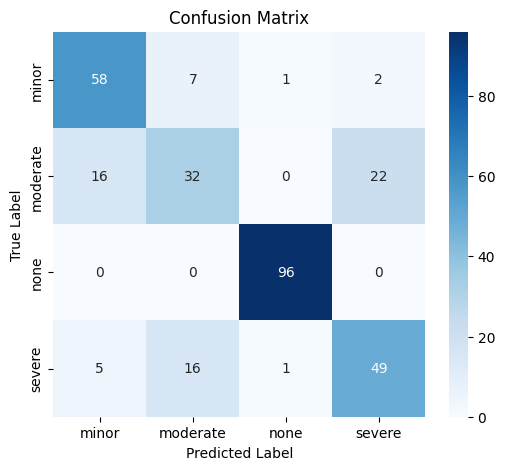

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers, optimizers
import tensorflow as tf

# Base model
base_mnv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_mnv2.trainable = False

# Top layers
x = layers.GlobalAveragePooling2D()(base_mnv2.output)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model_mnv2 = Model(inputs=base_mnv2.input, outputs=output)
model_mnv2.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train top layers
history_mnv2_stage1_obj = model_mnv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight
)
history_mnv2_stage1 = history_mnv2_stage1_obj.history

# Fine-tuning
base_mnv2.trainable = True
for layer in base_mnv2.layers[:-120]:  # unfreeze last 120 layers
    layer.trainable = False

model_mnv2.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Applying callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
    )
]

history_mnv2_stage2_obj = model_mnv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=18,
    class_weight=class_weight,
    callbacks=callbacks
)
history_mnv2_stage2 = history_mnv2_stage2_obj.history

# Merge history
history_mnv2 = {
    'accuracy': history_mnv2_stage1['accuracy'] + history_mnv2_stage2['accuracy'],
    'val_accuracy': history_mnv2_stage1['val_accuracy'] + history_mnv2_stage2['val_accuracy'],
    'loss': history_mnv2_stage1['loss'] + history_mnv2_stage2['loss'],
    'val_loss': history_mnv2_stage1['val_loss'] + history_mnv2_stage2['val_loss'],
}

# Save model
model_mnv2.evaluate(test_ds)
model_mnv2.save('model2_mobilenetV2.h5')

# Evaluate model
plot_history(history_mnv2, "MobileNetV2")
evaluate_model(model_mnv2, test_ds, class_names)
